<a href="https://colab.research.google.com/github/thul-aa/python-finacial-perfomance-analysis-/blob/main/Financial_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
df = pd.read_csv("sales_data2.csv", sep=";")
df.head()

,Order ID,Date,Region,Product,Quantity,Revenue,Expenses
0,C100,01/01/2020,Gauteng,Laptop,10,R50 000,R13 500
1,C101,02/01/2020,Gauteng,Phone,12,R53 000,R20 799
2,C102,03/01/2020,Gauteng,Phone,100,R78 000,R50 000
3,C103,04/01/2020,Gauteng,iPad,9,R40 000,R16 432
4,C104,05/01/2020,Gauteng,iPad,2,R20 000,R25 600


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order ID  364 non-null    object
 1   Date      364 non-null    object
 2   Region    364 non-null    object
 3   Product   364 non-null    object
 4   Quantity  364 non-null    int64 
 5   Revenue   364 non-null    object
 6   Expenses  364 non-null    object
dtypes: int64(1), object(6)
memory usage: 20.0+ KB


In [ ]:
df[['Revenue', 'Expenses']].head(10)

,Revenue,Expenses
0,R50 000,R13 500
1,R53 000,R20 799
2,R78 000,R50 000
3,R40 000,R16 432
4,R20 000,R25 600
5,R25 000,R600
6,R43 000,R31 798
7,R67 000,R0
8,R78 300,R0
9,R25 000,R0


In [ ]:
df['Revenue'] = df['Revenue'].str.replace('[R$,\s]', '', regex=True).astype(float)
df['Expenses'] = df['Expenses'].str.replace('[R$,\s]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_968/3936093833.py:1: SyntaxWarning: invalid escape sequence '\s'
  df['Revenue'] = df['Revenue'].str.replace('[R$,\s]', '', regex=True).astype(float)
/tmp/ipykernel_968/3936093833.py:2: SyntaxWarning: invalid escape sequence '\s'
  df['Expenses'] = df['Expenses'].str.replace('[R$,\s]', '', regex=True).astype(float)


In [ ]:
df.isnull().sum()

,0
Order ID,0
Date,0
Region,0
Product,0
Quantity,0
Revenue,0
Expenses,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [ ]:
df.dtypes

,0
Order ID,object
Date,datetime64[ns]
Region,object
Product,object
Quantity,int64
Revenue,float64
Expenses,float64


In [ ]:
df["Profit"] = df["Revenue"] - df["Expenses"]
df.head()

,Order ID,Date,Region,Product,Quantity,Revenue,Expenses,Profit
0,C100,2020-01-01,Gauteng,Laptop,10,50000.0,13500.0,36500.0
1,C101,2020-01-02,Gauteng,Phone,12,53000.0,20799.0,32201.0
2,C102,2020-01-03,Gauteng,Phone,100,78000.0,50000.0,28000.0
3,C103,2020-01-04,Gauteng,iPad,9,40000.0,16432.0,23568.0
4,C104,2020-01-05,Gauteng,iPad,2,20000.0,25600.0,-5600.0


In [ ]:
df["Profit_Margin"] = (df["Profit"] / df["Revenue"]) * 100
df.head()

,Order ID,Date,Region,Product,Quantity,Revenue,Expenses,Profit,Profit_Margin
0,C100,2020-01-01,Gauteng,Laptop,10,50000.0,13500.0,36500.0,73.000000
1,C101,2020-01-02,Gauteng,Phone,12,53000.0,20799.0,32201.0,60.756604
2,C102,2020-01-03,Gauteng,Phone,100,78000.0,50000.0,28000.0,35.897436
3,C103,2020-01-04,Gauteng,iPad,9,40000.0,16432.0,23568.0,58.920000
4,C104,2020-01-05,Gauteng,iPad,2,20000.0,25600.0,-5600.0,-28.000000


In [ ]:
Total_Revenue = df["Revenue"].sum()
print("Total Revenue:", Total_Revenue)

Total Revenue: 16014342.0


In [ ]:
Total_Expenses = df["Expenses"].sum()
print("Total Expenses:", Total_Expenses)

Total Expenses: 4830503.0


In [ ]:
revenue_by_region = df.groupby("Region")["Revenue"].sum()
revenue_by_region.sort_values(ascending=False)

,Revenue
Region,
Western Cape,6389106.0
Gauteng,5159461.0
Eastern Cape,4465775.0


In [ ]:
profit_by_region = df.groupby("Region")["Revenue"].sum()
profit_by_region.sort_values(ascending=False)

,Revenue
Region,
Western Cape,6389106.0
Gauteng,5159461.0
Eastern Cape,4465775.0


In [ ]:
revenue_by_product = df.groupby("Product")["Revenue"].sum()
revenue_by_product.sort_values(ascending=False)

,Revenue
Product,
Laptop,5799232.0
iPad,5249380.0
Phone,4965730.0


In [ ]:
units_by_product = df.groupby("Product")["Quantity"].sum()
units_by_product.sort_values(ascending=False)


,Quantity
Product,
Phone,2219
Laptop,1540
iPad,1529


In [ ]:
df["Month"] = df["Date"].dt.month

In [ ]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()
monthly_revenue.sort_values(ascending=False)

,Revenue
Month,
12,1862775.0
7,1736854.0
6,1520775.0
8,1481189.0
5,1450620.0
10,1402289.0
1,1330767.0
4,1196467.0
3,1185604.0


In [ ]:
monthly_profit = df.groupby("Month")["Profit"].sum()
monthly_profit.sort_values(ascending=False)

,Profit
Month,
12,1218071.0
6,1181937.0
5,1152793.0
10,1022312.0
1,990898.0
2,986409.0
4,939379.0
8,868271.0
7,760420.0


In [ ]:
import matplotlib.pyplot as plt


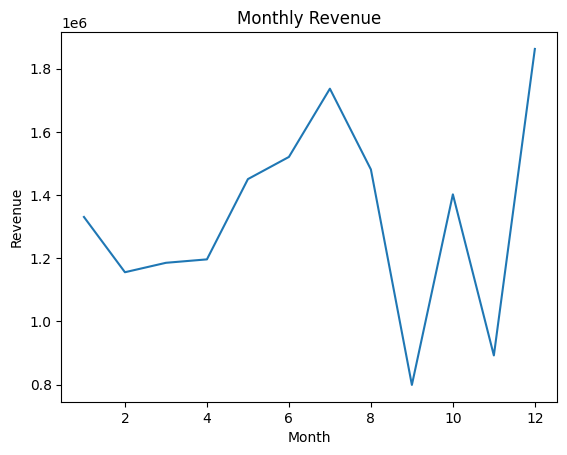

In [ ]:
monthly_revenue.plot(kind="line")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


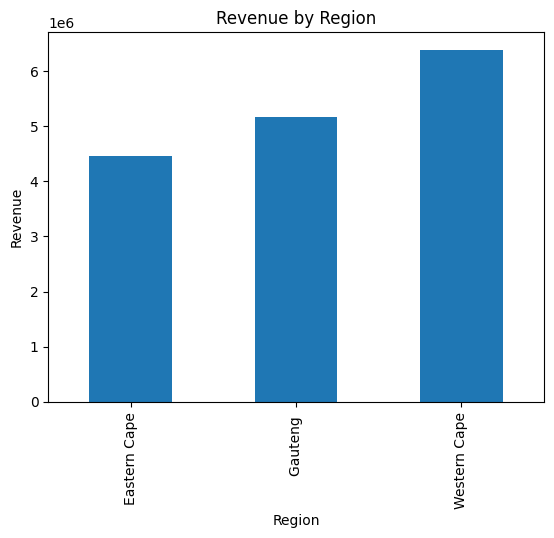

In [ ]:
revenue_by_region.plot(kind="bar")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()


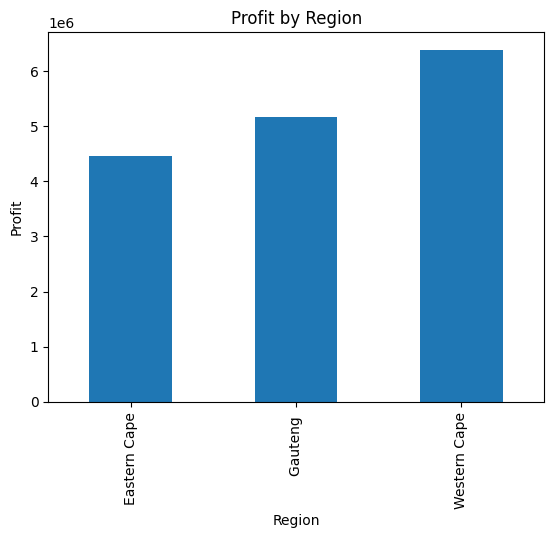

In [ ]:
profit_by_region.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

In [ ]:
monthly_revenue.max()

1862775.0

In [ ]:
monthly_revenue.min()

798969.0

Key Findings:
   Revenue:
   The Region that genetated the most revenue during the financial period is Western Cape with a total revenue of R6 389 106.0.
   Products:
   The product that was sold the most were phones with 2 219 units of mobile phone sold in a period of 12 months.
